## 0. Install & Import Dependencies

In [1]:
from importlib.metadata import version
pkgs = ["torch", "tiktoken", "tqdm", "matplotlib"]
for p in pkgs:
    try:
        print(f"{p}: {version(p)}")
    except Exception:
        print(f"{p}: not found")


torch: 2.10.0+cu128
tiktoken: 0.12.0
tqdm: 4.67.3
matplotlib: 3.10.0


In [2]:
import json
import time
import unicodedata
import torch
import tiktoken
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from functools import partial
from tqdm import tqdm


## 1. Device Setup
The book's original code only checks for CUDA. We add MPS support for Apple Silicon (M1/M2/M3/M4/M5 Macs).


In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cuda


## 2. Dataset Preparation: Kana-Only Japanese Sentences

We use `pykakasi` to convert kanji → hiragana, then format entries as Alpaca-style instruction pairs (Ch. 7).

Each entry looks like:
```json
{
  "instruction": "ひらがなだけでかいてください：",
  "input": "東京は大きい都市です。",
  "output": "とうきょうはおおきいとしです。"
}
```


In [4]:
!pip install pykakasi

In [5]:
import pykakasi

kks = pykakasi.kakasi()

def to_hiragana_only(text: str) -> str:
    """Convert all kanji/katakana in text to hiragana. Preserve punctuation."""
    result = kks.convert(text)
    return ''.join(item['hira'] if item['hira'] else item['orig'] for item in result)

def has_kanji(text: str) -> bool:
    """Return True if text contains any kanji characters."""
    return any('CJK' in unicodedata.name(c, '') for c in text)

def kanji_ratio(text: str) -> float:
    """Return the fraction of characters that are kanji (0.0 = perfect kana-only)."""
    if not text:
        return 0.0
    return sum(1 for c in text if 'CJK' in unicodedata.name(c, '')) / len(text)

# Test
test_sentence = "東京は大きい都市です。"
converted = to_hiragana_only(test_sentence)
print(f"Original : {test_sentence}")
print(f"Converted: {converted}")
print(f"Has kanji: {has_kanji(converted)}")


Original : 東京は大きい都市です。
Converted: とうきょうはおおきいとしです。
Has kanji: False


In [6]:
import random

# Beginner Japanese sentences (N5/N4 level)
RAW_SENTENCES = [
    # Greetings
    'おはようございます。', 'こんにちは。', 'こんばんは。', 'おやすみなさい。',
    'ありがとうございます。', 'どういたしまして。', 'すみません。', 'ごめんなさい。',
    'はじめまして。', 'よろしくおねがいします。', 'さようなら。', 'またね。',
    # Self-introduction
    'わたしは学生です。', 'わたしはアメリカ人です。', 'わたしの名前はジョアンナです。',
    'わたしは日本語を勉強しています。', 'わたしは二十三歳です。',
    'わたしはフィリピン出身です。', 'わたしはエンジニアです。',
    'わたしは医者です。', 'わたしは先生です。', 'わたしは大学院生です。',
    # This / That / Here / There
    'これは本です。', 'あれは車です。', 'それはかばんです。',
    'ここは学校です。', 'あそこはお店です。', 'そこは公園です。',
    'この本は面白いです。', 'その映画は好きです。', 'あの建物は古いです。',
    # Adjectives
    '天気がいいです。', '今日は暑いです。', '今日は寒いです。', '風が強いです。',
    'この部屋は広いです。', 'あの店は小さいです。', 'この道は長いです。',
    'そのかばんは重いです。', 'この問題は難しいです。', 'その本は易しいです。',
    # Food & drink
    'ご飯を食べます。', 'お水を飲みます。', 'コーヒーが好きです。',
    'すしはおいしいです。', 'パンを買います。', 'お茶を飲みます。',
    'ラーメンが食べたいです。', 'ケーキは甘いです。', 'このりんごは新鮮です。',
    'レストランで食べます。', '朝ごはんはパンです。', '夜ごはんはご飯です。',
    # Daily actions
    '学校へ行きます。', '家に帰ります。', '本を読みます。', '音楽を聞きます。',
    'テレビを見ます。', '友達と話します。', '日本語を練習します。',
    '毎朝シャワーを浴びます。', '歯を磨きます。', '服を着替えます。',
    '電車に乗ります。', '車を運転します。', '自転車に乗ります。',
    # Time expressions
    '今日は月曜日です。', '明日は火曜日です。', '今、七時です。',
    '毎日、日本語を勉強します。', '週末に映画を見ます。',
    '昨日は疲れました。', '明日は学校があります。', '来週、試験があります。',
    '今月は忙しいです。', '去年、日本に行きました。',
    # Location
    '東京は大きい都市です。', '駅はどこですか。', 'トイレはあそこです。',
    'スーパーは近いです。', '学校は遠いです。', '銀行は右にあります。',
    '病院は左にあります。', 'コンビニは前にあります。', '公園は後ろにあります。',
    # Questions
    'お名前は何ですか。', 'おいくつですか。', 'どこから来ましたか。',
    'これはいくらですか。', '今何時ですか。', 'どこに行きますか。',
    '何が好きですか。', 'どんな音楽が好きですか。', 'いつ来ますか。',
    # Weather
    '今日は晴れです。', '雨が降っています。', '曇りです。', '雪が降っています。',
    '台風が来ます。', '春は暖かいです。', '夏は暑いです。', '秋は涼しいです。', '冬は寒いです。',
    # Shopping
    'これをください。', 'いくらですか。', 'ちょっと高いです。', 'やすいですね。',
    'クレジットカードで払います。', '現金で払います。', 'レシートをください。',
    'これはセールですか。', 'サイズはありますか。', '色が好きです。',
    # Feelings
    '嬉しいです。', '悲しいです。', '疲れました。', '眠いです。', '元気です。',
    '緊張しています。', 'わくわくしています。', 'びっくりしました。',
    '心配しています。', 'リラックスしています。',
    # Hobbies
    '音楽が好きです。', '本を読むのが好きです。', '旅行が好きです。',
    'スポーツをします。', '料理を作ります。', '絵を描きます。',
    '写真を撮ります。', 'ゲームをします。', '映画を見るのが好きです。',
    # Family
    '家族は五人です。', '父は会社員です。', '母は主婦です。',
    '兄は大学生です。', '妹は高校生です。', '祖母は七十歳です。',
    # Health
    '体の調子がいいです。', '頭が痛いです。', '熱があります。',
    '病院に行きます。', '薬を飲みます。', 'よく寝てください。',
    # Study
    '授業は九時から始まります。', '宿題をします。', 'テストがあります。',
    '図書館で勉強します。', '先生に質問します。', '友達と一緒に勉強します。',
    # Giving / receiving
    'プレゼントをもらいました。', '花をあげます。', '手紙を書きます。',
    '電話をかけます。', 'メールを送ります。',
    # Transport
    '電車で行きます。', 'バスに乗ります。', 'タクシーを呼びます。',
    '歩いて行きます。', '飛行機で旅行します。',
    # Simple past
    '昨日、映画を見ました。', '先週、友達と会いました。', '朝ごはんを食べました。',
    '日本語を勉強しました。', '公園を散歩しました。',
    # Wants
    '日本に行きたいです。', '新しいパソコンが欲しいです。', '日本語が上手になりたいです。',
    'もっと練習したいです。', '早く寝たいです。',
    # Requests
    'もう一度言ってください。', 'ゆっくり話してください。', 'ちょっと待ってください。',
    '手伝ってください。', '見せてください。',
    # Te-form / connecting actions
    '起きて、シャワーを浴びます。', '食べて、歯を磨きます。', '勉強して、寝ます。',
    '着替えて、学校へ行きます。', '帰って、ご飯を食べます。',
    # Negative forms
    '今日は学校に行きません。', '肉を食べません。', 'お酒を飲みません。',
    'テレビを見ません。', '日本語がわかりません。', 'お金がありません。',
    'バスに乗りません。', '今日は忙しくありません。', '寒くありません。',
    # Past negative
    '昨日は食べませんでした。', '先週は勉強しませんでした。', '映画を見ませんでした。',
    # Can / cannot
    '日本語が話せます。', '車が運転できます。', '料理が作れます。',
    '泳ぐことができます。', 'ピアノが弾けます。', '漢字が読めません。',
    '早く走れません。', '高い山に登れません。',
    # Giving and receiving
    '友達にプレゼントをあげました。', '母からお菓子をもらいました。',
    '先生に本を借りました。', '図書館に本を返しました。',
    # Comparisons
    '犬より猫が好きです。', '夏より冬が好きです。', 'バスより電車が速いです。',
    'りんごよりみかんが甘いです。', 'この店より安いです。',
    # Suggestions / invitations
    '一緒に映画を見ませんか。', '昼ご飯を食べませんか。', '公園へ行きませんか。',
    'お茶を飲みませんか。', 'カラオケに行きましょう。', '一緒に勉強しましょう。',
    # Existence
    '冷蔵庫にりんごがあります。', '机の上に本があります。', '部屋に猫がいます。',
    '公園に子供がいます。', '駐車場に車があります。', '財布にお金があります。',
    '近くにコンビニがあります。', '家の前に木があります。',
    # Directions
    '右に曲がってください。', '左に曲がってください。', 'まっすぐ行ってください。',
    '交差点を渡ってください。', '橋を渡ります。', '坂を上ります。',
    # Numbers and counting
    'りんごを三つ買いました。', '本を五冊読みました。', '水を二本飲みました。',
    '友達が六人います。', 'クラスに二十人います。', '猫が二匹います。',
    # Reasons (から)
    '眠いから早く寝ます。', '雨だから傘を持ちます。', '寒いからコートを着ます。',
    '好きだから毎日食べます。', '大切だから練習します。',
    # When (とき)
    '疲れた時、休みます。', '暇な時、本を読みます。', '悲しい時、音楽を聞きます。',
    '日本に行った時、すしを食べました。',
    # Body parts
    '目が痛いです。', '耳が聞こえません。', '足が疲れました。',
    '手を洗います。', '背が高いです。', '髪が長いです。',
    # Clothes
    '今日は青いシャツを着ています。', '黒いズボンをはいています。',
    '白いワンピースが好きです。', '帽子をかぶります。', '手袋をはめます。',
    # Nature
    '川の水がきれいです。', '山の景色が美しいです。', '海で泳ぎます。',
    '花が咲いています。', '葉っぱが落ちています。', '星がきれいです。',
    # School / study
    '今日は数学のテストがあります。', '英語の宿題をしました。',
    '歴史の授業が好きです。', '体育の授業は楽しいです。', '給食を食べました。',
    '放課後、図書館で勉強します。', '先生の話を聞きます。',
    # Work
    '毎朝九時に出勤します。', '会議に出席します。', 'メールを送りました。',
    '報告書を書きます。', '電話に出ます。', '仕事が終わりました。',
    # Weekend / free time
    '週末に友達と遊びます。', '日曜日に家族と出かけます。',
    '土曜日に掃除をします。', '休みの日に料理をします。',
    # Opinions
    'この映画は面白いと思います。', '日本語は難しいと思います。',
    'この店はおいしいと思います。', '明日は晴れると思います。',
    # Plans
    '来年、日本に行くつもりです。', '大学院に進学するつもりです。',
    '来月、引っ越しします。', '今年中に免許を取ります。',
    # Shopping details
    'このサイズはありますか。', '試着してもいいですか。', '袋をください。',
    '領収書をお願いします。', 'セールはいつですか。', 'ポイントカードがあります。',
    # Restaurant
    'メニューを見せてください。', '注文してもいいですか。', 'お水をください。',
    'お会計をお願いします。', 'おすすめは何ですか。', 'テイクアウトできますか。',
    # Feelings expanded
    'とても楽しかったです。', '少し心配です。', 'すごく嬉しいです。',
    'ちょっと恥ずかしいです。', 'とても驚きました。', '少し寂しいです。',
    # Apologizing / thanking
    '遅れてごめんなさい。', 'ご迷惑をおかけしました。', 'お世話になりました。',
    'ありがとうございました。', 'お疲れ様でした。', 'よくできました。',
    # Phone / internet
    'スマホを使います。', 'インターネットで調べます。', '写真を撮りました。',
    'メッセージを送ります。', 'アプリをダウンロードします。',
    # Simple conditionals
    '雨が降ったら、家にいます。', '時間があれば、行きます。',
    'お金があったら、旅行します。', '晴れたら、公園へ行きます。',
]

# Instructions (Written in Hiragana so it remains in kana mode)
INSTRUCTIONS = [
    "ひらがなとかたかなだけで、かんじをつかわずにかいてください：",
    "やさしいにほんごで、かんじなしでかいてください：",
    "ひらがなだけでかいてください：",
    "にほんごをひらがなにしてください：",
    "かんじをつかわないでかいてください：",
]

def build_dataset(sentences):
    """Convert sentences to hiragana and format as instruction-response pairs."""
    dataset = []
    for sentence in sentences:
        converted = to_hiragana_only(sentence)
        if has_kanji(converted) or len(converted.strip()) < 3:
            continue
        dataset.append({
            "instruction": random.choice(INSTRUCTIONS),
            "input": sentence,
            "output": converted,
        })
    return dataset

random.seed(42)
data = build_dataset(RAW_SENTENCES)
print(f"Total examples: {len(data)}")
print("\nSample entry:")
print(json.dumps(data[0], ensure_ascii=False, indent=2))


Total examples: 319

Sample entry:
{
  "instruction": "ひらがなとかたかなだけで、かんじをつかわずにかいてください：",
  "input": "おはようございます。",
  "output": "おはようございます。"
}


In [7]:
# Train / val / test split (85 / 10 / 5) — same ratios as Ch. 7
random.seed(42)
random.shuffle(data)

train_portion = int(len(data) * 0.85)
test_portion  = int(len(data) * 0.10)
val_portion   = len(data) - train_portion - test_portion

train_data = data[:train_portion]
test_data  = data[train_portion:train_portion + test_portion]
val_data   = data[train_portion + test_portion:]

print(f"Train : {len(train_data)}")
print(f"Val   : {len(val_data)}")
print(f"Test  : {len(test_data)}")


Train : 271
Val   : 17
Test  : 31


## 3. Prompt Formatting (Ch. 7 Alpaca Style)
Same `format_input` function from the book — no changes needed.


In [8]:
def format_input(entry):
    """Alpaca-style prompt format from Ch. 7."""
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )
    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    return instruction_text + input_text

# Preview
sample = train_data[0]
print(format_input(sample))
print(f"\n### Response:\n{sample['output']}")


Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
やさしいにほんごで、かんじなしでかいてください：

### Input:
電話に出ます。

### Response:
でんわにでます。


## 4. InstructionDataset & DataLoader
Directly from Ch. 7 — `InstructionDataset` and `custom_collate_fn` unchanged.


In [9]:
tokenizer = tiktoken.get_encoding("gpt2")

class InstructionDataset(Dataset):
    """From Ch. 7 — tokenizes instruction+response pairs."""
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(tokenizer.encode(full_text))

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)


def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
    """From Ch. 7 — pads batches and masks padding with -100."""
    batch_max_length = max(len(item) + 1 for item in batch)
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        inputs  = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])

        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        if allowed_max_length is not None:
            inputs  = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor  = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor


customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)

num_workers = 0
batch_size  = 2
torch.manual_seed(123)

train_loader = DataLoader(InstructionDataset(train_data, tokenizer),
    batch_size=batch_size, collate_fn=customized_collate_fn,
    shuffle=True, drop_last=True, num_workers=num_workers)

val_loader = DataLoader(InstructionDataset(val_data, tokenizer),
    batch_size=batch_size, collate_fn=customized_collate_fn,
    shuffle=False, drop_last=False, num_workers=num_workers)

test_loader = DataLoader(InstructionDataset(test_data, tokenizer),
    batch_size=batch_size, collate_fn=customized_collate_fn,
    shuffle=False, drop_last=False, num_workers=num_workers)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")


Train batches : 135
Val batches   : 9
Test batches  : 16


## 5. Load Pretrained GPT-2 (Ch. 7)
Same model loading code from the book. We use `gpt2-small (124M)` here for speed — swap to `gpt2-medium (355M)` for better results if you have time.

> **Note:** You need `previous_chapters.py` and `gpt_download.py` in the same directory.  
> Get them from: https://github.com/rasbt/LLMs-from-scratch/tree/main/ch07/01_main-chapter-code


Built in Google Colab and these cells are environment specific.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/Final Project')

In [ ]:
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt

BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True
}

model_configs = {
    "gpt2-small (124M)":  {"emb_dim": 768,  "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)":  {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)":    {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-small (124M)"

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")

settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

print(f"Loaded: {CHOOSE_MODEL}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe
Loaded: gpt2-small (124M)
Parameters: 163,037,184


## 6. Baseline: Generation BEFORE Fine-Tuning
This shows why fine-tuning is needed — the base model doesn't follow our kana-only instruction.


In [13]:
from previous_chapters import generate_text_simple, text_to_token_ids, token_ids_to_text

def get_response(model, entry, tokenizer, device, max_new_tokens=80):
    """Generate a response and extract just the output text."""
    input_text = format_input(entry)
    token_ids = generate_text_simple(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=max_new_tokens,
        context_size=BASE_CONFIG["context_length"],
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    return generated_text[len(input_text):].replace("### Response:", "").strip()

model.to(device)
torch.manual_seed(123)

print("BEFORE FINE-TUNING")
for entry in val_data[:3]:
    response = get_response(model, entry, tokenizer, device)
    print(f"\nInput      : {entry['input']}")
    print(f"Target     : {entry['output']}")
    print(f"Model out  : {response}")
    print(f"Kanji ratio: {kanji_ratio(response):.3f} (0.0 = perfect)")
    print("-" * 50)


BEFORE FINE-TUNING

Input      : 花が咲いています。
Target     : はながさいています。
Model out  : ### Output:

やさしいにほんごで、かんじなしでかいてください：

### Request:

やさしいにほんごで、かんじなしでかいてください：
Kanji ratio: 0.000 (0.0 = perfect)
--------------------------------------------------

Input      : わくわくしています。
Target     : わくわくしています。
Model out  : ### Output:

それは、それは、それは、それは、それは、それは、それは、それは、それは、それは、それは、それは、それは、それは、それ
Kanji ratio: 0.000 (0.0 = perfect)
--------------------------------------------------

Input      : サイズはありますか。
Target     : さいずはありますか。
Model out  : ### Output:

それは、それは、それは、それは、それは、それは、それは、それは、それは、それは、それは、それは、それは、それは、それ
Kanji ratio: 0.000 (0.0 = perfect)
--------------------------------------------------


## 7. Fine-Tuning (Ch. 7 `train_model_simple`)
The training loop is exactly from Ch. 7 — `train_model_simple` with `AdamW`, backpropagation runs automatically via `loss.backward()`.

**What backprop does here:**  
Loss is computed only on response tokens (prompt tokens are masked with `-100`). `loss.backward()` computes gradients flowing back through all 12/24 transformer layers. `optimizer.step()` nudges every weight to reduce loss on the next prediction.


In [14]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )
    return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

# Initial loss before training
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss   = calc_loss_loader(val_loader,   model, device, num_batches=5)

print(f"Before training — Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")

Before training — Train loss: 3.9979 | Val loss: 3.7930


In [15]:
import time

def train_model_simple(model, train_loader, val_loader, optimizer, device,
                       num_epochs, eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss = calc_loss_loader(train_loader, model, device, eval_iter)
                val_loss   = calc_loss_loader(val_loader,   model, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

    return train_losses, val_losses, track_tokens_seen

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(epochs_seen, train_losses, label="Train loss")
    ax1.plot(epochs_seen, val_losses, linestyle="--", label="Val loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()

In [16]:
start_time = time.time()
torch.manual_seed(123)

optimizer  = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)
num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

elapsed = (time.time() - start_time) / 60
print(f"\nTraining completed in {elapsed:.2f} minutes.")


Ep 1 (Step 000000): Train loss 2.998, Val loss 2.938
Ep 1 (Step 000005): Train loss 1.701, Val loss 1.606
Ep 1 (Step 000010): Train loss 1.159, Val loss 1.035
Ep 1 (Step 000015): Train loss 1.047, Val loss 0.877
Ep 1 (Step 000020): Train loss 0.712, Val loss 0.766
Ep 1 (Step 000025): Train loss 0.938, Val loss 0.697
Ep 1 (Step 000030): Train loss 0.685, Val loss 0.654
Ep 1 (Step 000035): Train loss 0.664, Val loss 0.625
Ep 1 (Step 000040): Train loss 0.706, Val loss 0.606
Ep 1 (Step 000045): Train loss 0.718, Val loss 0.593
Ep 1 (Step 000050): Train loss 0.582, Val loss 0.566
Ep 1 (Step 000055): Train loss 0.571, Val loss 0.575
Ep 1 (Step 000060): Train loss 0.625, Val loss 0.577
Ep 1 (Step 000065): Train loss 0.570, Val loss 0.595
Ep 1 (Step 000070): Train loss 0.617, Val loss 0.583
Ep 1 (Step 000075): Train loss 0.574, Val loss 0.552
Ep 1 (Step 000080): Train loss 0.526, Val loss 0.547
Ep 1 (Step 000085): Train loss 0.538, Val loss 0.562
Ep 1 (Step 000090): Train loss 0.542, Val loss

In [17]:
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(epochs_seen, train_losses, label="Train loss")
    ax1.plot(epochs_seen, val_losses, linestyle="--", label="Val loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()

print("Training functions defined!")

Training functions defined!


## 8. Controlled Output: Logit Masking for Kana-Only Generation

This is the novel contribution of the project.

**How it works:**  
At each generation step, GPT-2 outputs one logit score per vocabulary token (~50k tokens).  
We identify every token that contains a kanji character and set its logit to `-inf`.  
After softmax, `-inf` → probability of exactly `0.0` — the model **cannot** sample kanji.  

This is "controlled output representation": we control the output space at the logit level before any token is sampled.


In [18]:
def build_kanji_mask(tokenizer) -> torch.Tensor:
    """
    Build a boolean mask over the full GPT-2 vocabulary.
    True  = token contains kanji → block at inference
    False = safe token (hiragana, punctuation, etc.) → allow
    """
    vocab = tokenizer.n_vocab
    mask = torch.zeros(vocab, dtype=torch.bool)

    for idx in range(vocab):
        try:
            decoded = tokenizer.decode([idx])
        except Exception:
            continue
        if any('CJK' in unicodedata.name(c, '') for c in decoded):
            mask[idx] = True

    blocked = mask.sum().item()
    print(f"Vocabulary size : {vocab:,}")
    print(f"Kanji tokens    : {blocked:,} blocked ({blocked/vocab*100:.1f}%)")
    print(f"Safe tokens     : {vocab - blocked:,} allowed")
    return mask

kanji_mask = build_kanji_mask(tokenizer)


Vocabulary size : 50,257
Kanji tokens    : 51 blocked (0.1%)
Safe tokens     : 50,206 allowed


In [19]:
def generate_kana(model, idx, tokenizer, kanji_mask, max_new_tokens=20,
                  context_size=128, temperature=0.7, eos_id=50256):
    """
    Generate text with hard kana-only enforcement via logit masking.

    At each step:
      1. Run forward pass → get logits (one per vocab token)
      2. Set kanji token logits to -inf  ← controlled output mechanism
      3. Apply temperature scaling
      4. Softmax → probabilities
      5. Sample next token (kanji tokens have prob = 0.0)
    """
    model.eval()
    kanji_mask_device = kanji_mask.to(idx.device)

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]  # (batch, vocab_size)

        # ── CONTROLLED OUTPUT: zero out all kanji token logits ──────────
        logits[:, kanji_mask_device] = float('-inf')

        # Temperature scaling + sampling
        logits = logits / temperature
        probs  = torch.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)

        if idx_next.item() == eos_id:
            break

        idx = torch.cat((idx, idx_next), dim=1)

    return idx


def get_response_kana(model, entry, tokenizer, kanji_mask, device, max_new_tokens=80):
    """Generate a kana-only response using logit masking."""
    input_text = format_input(entry)
    idx = text_to_token_ids(input_text, tokenizer).to(device)
    token_ids = generate_kana(
        model=model,
        idx=idx,
        tokenizer=tokenizer,
        kanji_mask=kanji_mask,
        max_new_tokens=max_new_tokens,
        context_size=BASE_CONFIG["context_length"],
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    return generated_text[len(input_text):].replace("### Response:", "").strip()

print("Kana generation function ready!")


Kana generation function ready!


## 9. Evaluation: Before vs After Fine-Tuning vs Logit Masked

We compare three conditions:
- **Baseline**: Pre-trained GPT-2, no fine-tuning, no mask
- **Fine-tuned**: After instruction fine-tuning, no mask  
- **Fine-tuned + Mask**: Fine-tuned AND logit masking ← our full method

Key metric: **Kanji Ratio** (lower = better; 0.0 = perfect kana-only output)


In [20]:
# Reload baseline model for fair comparison
settings_base, params_base = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")
baseline_model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(baseline_model, params_base)
baseline_model.eval()
baseline_model.to(device)

print("Baseline model loaded for comparison.")


File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe
Baseline model loaded for comparison.


In [21]:
# Empty kanji mask = no blocking (for baseline/finetuned-only conditions)
no_mask = torch.zeros(tokenizer.n_vocab, dtype=torch.bool)

results = []
torch.manual_seed(123)

print("Evaluating test set...")
for entry in tqdm(test_data):
    # Condition A: Baseline (no fine-tuning, no mask)
    out_a = get_response_kana(baseline_model, entry, tokenizer, no_mask, device)

    # Condition B: Fine-tuned (no mask)
    out_b = get_response_kana(model, entry, tokenizer, no_mask, device)

    # Condition C: Fine-tuned + Logit Mask ← our full method
    out_c = get_response_kana(model, entry, tokenizer, kanji_mask, device)

    results.append({
        "input":    entry["input"],
        "target":   entry["output"],
        "baseline": out_a,
        "finetuned": out_b,
        "finetuned_masked": out_c,
    })

print("Done!")


Evaluating test set...


100%|██████████| 31/31 [01:17<00:00,  2.49s/it]

Done!


In [23]:
# Summary statistics
conditions = [
    ("A. Baseline GPT-2",            "baseline"),
    ("B. Fine-tuned (no mask)",       "finetuned"),
    ("C. Fine-tuned + Logit Mask",  "finetuned_masked"),
]

print(f"{'Condition':<35} {'Avg Kanji Ratio':>16} {'Kana-Only %':>12}")
print("-" * 66)

for label, key in conditions:
    ratios   = [kanji_ratio(r[key]) for r in results]
    avg_kr   = sum(ratios) / len(ratios)
    kana_pct = sum(1 for r in ratios if r == 0.0) / len(ratios) * 100
    print(f"{label:<35} {avg_kr:>16.4f} {kana_pct:>11.1f}%")


Condition                            Avg Kanji Ratio  Kana-Only %
------------------------------------------------------------------
A. Baseline GPT-2                             0.0244        67.7%
B. Fine-tuned (no mask)                       0.0000       100.0%
C. Fine-tuned + Logit Mask                    0.0000       100.0%


In [24]:
# ── Sample outputs ───────────────────────────────────────────────────────────
print("\n=== SAMPLE OUTPUTS (first 5 test examples) ===\n")
for i, r in enumerate(results[:5]):
    print(f"Example {i+1}")
    print(f"  Input    : {r['input']}")
    print(f"  Target   : {r['target']}")
    print(f"  A Base   : {r['baseline']}  [kanji={kanji_ratio(r['baseline']):.3f}]")
    print(f"  B FT     : {r['finetuned']}  [kanji={kanji_ratio(r['finetuned']):.3f}]")
    print(f"  C FT+Mask: {r['finetuned_masked']}  [kanji={kanji_ratio(r['finetuned_masked']):.3f}]")
    print()



=== SAMPLE OUTPUTS (first 5 test examples) ===

Example 1
  Input    : お金がありません。
  Target   : おきんがありません。
  A Base   : ### Output:

Author:

Release Date:

Bug Notes:

If you are running OS X Lion, do not use this command.

Downloads:

1. Install Xcode from http://download.xcode.org/download/download/1.0.4-2/xcode-1.0.4-2-  [kanji=0.000]
  B FT     : おいいがありません。  [kanji=0.000]
  C FT+Mask: おいいがありません。  [kanji=0.000]

Example 2
  Input    : プレゼントをもらいました。
  Target   : ぷれぜんとをもらいました。
  A Base   : ### Output:

やさしいにほんごで、かんじなしでかいてください：

### Preparing a Response

The next instruction gives the user a suitable response.

### Instruction:

やさしいにほんごで、かんじ  [kanji=0.000]
  B FT     : にほんごとをもらいました。  [kanji=0.000]
  C FT+Mask: とからっともいました。  [kanji=0.000]

Example 3
  Input    : その本は易しいです。
  Target   : そのほんはやさしいです。
  A Base   : その本は易しいです。

### Request:

その本は易しいです。

### Handling:

この本に決している。

### Process:

162. Comparing two statements

In the example, we  [kanji=0.047]
  B FT     : そのせいがしいです。  [kanji=0.

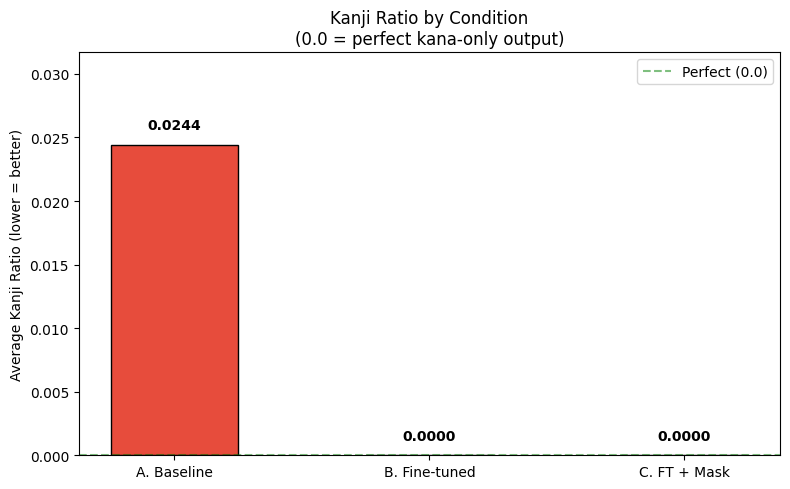

In [26]:
# Bar chart of kanji ratio by condition
labels = ["A. Baseline", "B. Fine-tuned", "C. FT + Mask"]
avg_ratios = [
    sum(kanji_ratio(r["baseline"]) for r in results) / len(results),
    sum(kanji_ratio(r["finetuned"]) for r in results) / len(results),
    sum(kanji_ratio(r["finetuned_masked"]) for r in results) / len(results),
]

colors = ["#e74c3c", "#f39c12", "#2ecc71"]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, avg_ratios, color=colors, width=0.5, edgecolor="black")
ax.set_ylabel("Average Kanji Ratio (lower = better)")
ax.set_title("Kanji Ratio by Condition\n(0.0 = perfect kana-only output)")
ax.set_ylim(0, max(avg_ratios) * 1.3)

for bar, val in zip(bars, avg_ratios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{val:.4f}", ha="center", va="bottom", fontweight="bold")

ax.axhline(y=0, color="green", linestyle="--", alpha=0.5, label="Perfect (0.0)")
ax.legend()
plt.tight_layout()
plt.savefig("kanji_ratio_comparison.png", dpi=150)
plt.show()


## 10. Save Model

In [27]:
import re

file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL)}-kana-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved: {file_name}")

# Save results
with open("kana_test_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
print("Results saved: kana_test_results.json")


Model saved: gpt2-small124M-kana-sft.pth
Results saved: kana_test_results.json
